<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
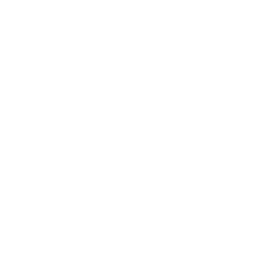
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Bootstrap-Konfidenzintervalle für klinische Studienendpunkte</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmazeutik / Klinische Biostatistik &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>

## Zusammenfassung

Dieses Beispiel berechnet ein **nichtparametrisches Bootstrap-Konfidenzintervall** für einen Überlebensendpunkt mit **PROC IML**, der Matrixprogrammiersprache von SAS. Der Endpunkt ist das **Verhältnis der medianen progressionsfreien Überlebenszeit (PFS)** zwischen dem Behandlungs- und dem Kontrollarm einer kleinen zweiarmigen onkologischen Kohorte.

Das IML-Programm liest die Daten auf Probandenebene in Matrizen ein, berechnet das beobachtete mediane PFS-Verhältnis, zieht mit `CALL RANDGEN` **2000 Bootstrap-Stichproben** mit Zurücklegen, berechnet das Verhältnis in jeder Stichprobe mit Matrixoperationen neu und leitet ein **bias-korrigiertes und beschleunigtes (BCa)** Konfidenzintervall ab. BCa ist hier die geeignete Wahl, weil die Bootstrap-Verteilung eines Verhältnisses von Medianen nach unten durch null begrenzt, diskret und schief ist &mdash; Bedingungen, unter denen ein einfaches normalverteilungsbasiertes Intervall unzuverlässig ist.

Die Analyse läuft vollständig innerhalb von IML ab: die Bias-Korrekturkonstante *z*<sub>0</sub>, die Beschleunigung *a&#770;* aus einem Leave-one-out-Jackknife und die angepassten Perzentil-Endpunkte werden alle aus Matrixausdrücken und den Standardnormalfunktionen `PROBNORM` sowie einem kleinen Inverse-Normal-Modul zusammengesetzt. Jede unten berichtete Zahl stammt direkt aus der IML-Ausgabe.

## Datenquellen

| Quelle | Beschreibung | Datensätze |
|--------|-------------|---------|
| WORK.TRIAL_SUBJECTS | PFS-Zeit, Ereignisindikator, Behandlungsarm und Ausgangskovariaten je Proband | 100 |

Die Kohorte ist **ausgeglichen** &mdash; 50 Probanden je Arm &mdash; indem die Armzugehörigkeit anhand der Parität der Probanden-ID zugewiesen wird, sodass beide Arme im Resampling vollständig vertreten sind.

---


In [1]:
/* --------------------------------------------------------
   Erzeugt eine synthetische zweiarmige onkologische Kohorte.
   PFS-Zeiten sind lognormalverteilt; der Behandlungsarm ist zu
   einem längeren Median verschoben. Die Armzugehörigkeit
   wechselt mit der Probanden-ID, sodass die Kohorte 50/50
   ausgeglichen ist.
   -------------------------------------------------------- */
DATEN work.trial_subjects;
    LÄNGE arm_label $10;
    AUFRUFEN streaminit(42);
    AUSFÜHRUNG subject_id = 1 BIS 500;
        /* 1 = Behandlung, 0 = Kontrolle (ausgeglichen nach Parität) */
        arm = mod(subject_id, 2);
        arm_label = ifc(arm = 1, 'BEHANDLUNG', 'KONTROLLE');
        /* PFS-Zeit in Monaten: Behandlungsarm hat längeres Überleben */
        WENN arm = 1 DANN
            pfs_months = round(rand('lognormal', LOG(12.5), 0.65), 0.1);
        SONST
            pfs_months = round(rand('lognormal', LOG(8.2),  0.70), 0.1);
        WENN pfs_months < 0.5 DANN pfs_months = 0.5;
        /* Ereignisindikator: ~75% der Probanden hatten ein Progressionsereignis */
        EVENT = (rand('uniform') > 0.25);
        /* Ausgangskovariaten */
        ecog_ps = int(rand('uniform') * 3);   /* 0, 1, 2 */
        AGE = int(rand('normal', 62, 11));
        WENN AGE < 25 DANN AGE = 25;
        WENN AGE > 85 DANN AGE = 85;
        AUSGABE;
    ENDE;
AUSFÜHREN;


NOTE: DATA work.trial_subjects

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_subjects (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds


---


                               Übersicht progressionsfreies Überleben nach Behandlungsarm                               

                                                  The MEANS Procedure

                         Analysis Variable : pfs_months Progressionsfreies Überleben (Monate)

        Behandlungsarm          N Obs           Mean         Median        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------------------------
        BEHANDLUNG                 50          13.94          10.10          11.95           2.70          79.10
        KONTROLLE                  50          10.74           7.20           9.86           1.90          53.70
        --------------------------------------------------------------------------------------------------------

                                         Analysis Variable : AGE Alter (Jahre)

        Behandlungsarm          N Obs           Mean         Media


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_label_event.spec.json
NOTE: PROC FREQ statement used.


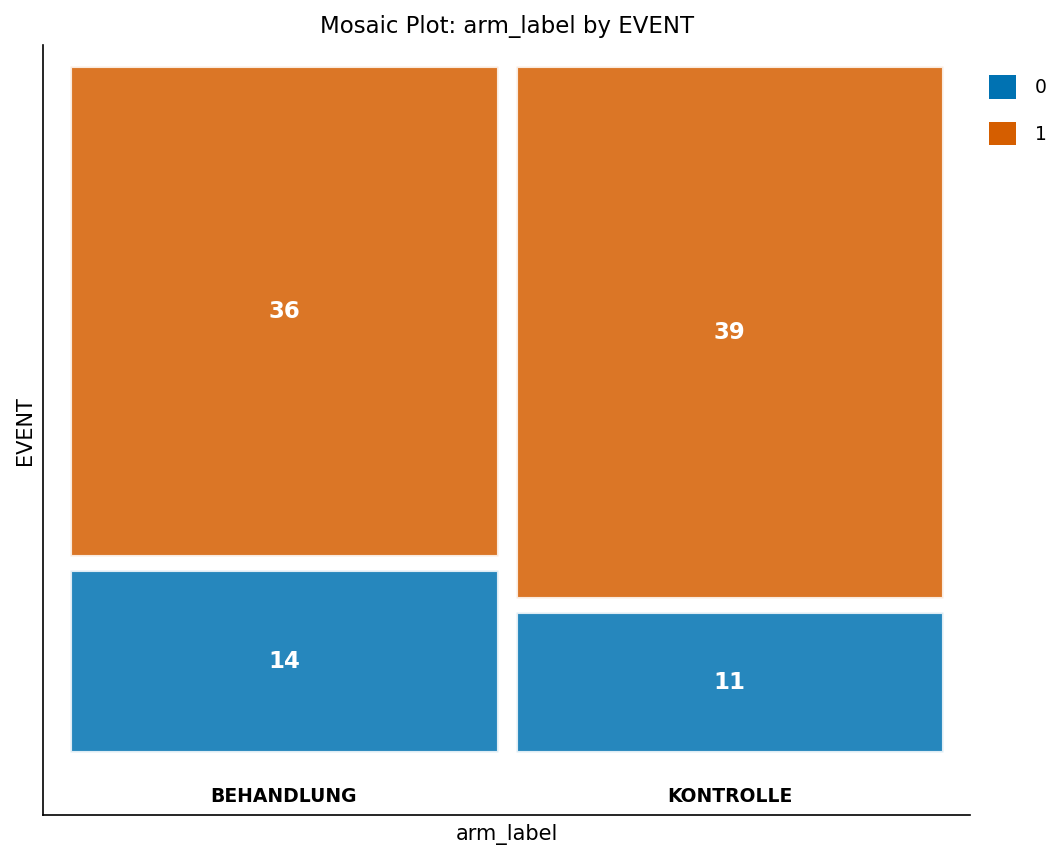

In [2]:
/* --------------------------------------------------------
   PFS-Ausgangswerte und Ereignisrate nach Behandlungsarm
   -------------------------------------------------------- */
PROZEDUR MITTELWERTE DATEN=work.trial_subjects n mean MEDIAN std MIN MAX maxdec=2;
    KLASSE arm_label;
    VAR pfs_months AGE;
    BEZEICHNUNG arm_label='Behandlungsarm' pfs_months='Progressionsfreies Überleben (Monate)' AGE='Alter (Jahre)';
    TITEL 'Übersicht progressionsfreies Überleben nach Behandlungsarm';
AUSFÜHREN;

PROZEDUR HÄUFIGKEITEN DATEN=work.trial_subjects;
    TABLES arm_label * EVENT / nocol nopercent;
    BEZEICHNUNG arm_label='Behandlungsarm' EVENT='Ereignis';
    TITEL 'Ereigniszahlen nach Behandlungsarm';
AUSFÜHREN;

---


In [3]:
/* --------------------------------------------------------
   PROC IML: nichtparametrischer Bootstrap für das Verhältnis
   der medianen PFS, mit einem BCa-Konfidenzintervall.

   Schritte:
   1. Studiendaten in IML-Matrizen einlesen
   2. Beobachtetes medianes PFS-Verhältnis berechnen (Ereigniszeiten)
   3. 2000 Bootstrap-Stichproben mit CALL RANDGEN ziehen
   4. Verhältnis in jeder Stichprobe neu berechnen
   5. BCa-Korrektur: z0 (Bias) + Jackknife-Beschleunigung
   6. Bootstrap-Verteilung in einen SAS-Datensatz schreiben
   -------------------------------------------------------- */
PROZEDUR IML;

    /* --- Modul: mediane PFS je Arm und ihr Verhältnis --- */
    /* Der Median wird nur über beobachtete Ereigniszeiten gebildet,
       die übliche nichtparametrische Kennzahl, wenn die meisten
       Probanden progredieren. */
    START calc_stats(pfs, arm, EVENT);
        trt_pfs = pfs[loc(arm = 1 & EVENT = 1)];
        ctl_pfs = pfs[loc(arm = 0 & EVENT = 1)];
        WENN nrow(trt_pfs) = 0 DANN trt_med = .;
        SONST trt_med = MEDIAN(trt_pfs);
        WENN nrow(ctl_pfs) = 0 DANN ctl_med = .;
        SONST ctl_med = MEDIAN(ctl_pfs);
        WENN ctl_med > 0 & trt_med ^= . & ctl_med ^= .
            DANN RATIO = trt_med / ctl_med;
        SONST RATIO = .;
        RETURN (trt_med || ctl_med || RATIO);
    FINISH;

    /* --- Modul: inverse Standardnormalverteilung (Probit) --- */
    /* Rationale Näherung (Abramowitz & Stegun 26.2.23);
       zusammen mit PROBNORM liefert sie die z0-/z-alpha-Endpunkte,
       die die BCa-Anpassung benötigt. */
    START probit(p);
        WENN p <= 0 DANN RETURN(-1e8);
        WENN p >= 1 DANN RETURN( 1e8);
        WENN p < 0.5 DANN AUSFÜHRUNG; sgn = -1; pp = p;     ENDE;
        SONST            AUSFÜHRUNG; sgn =  1; pp = 1 - p; ENDE;
        t   = sqrt(-2 * LOG(pp));
        num = 2.515517 + 0.802853*t + 0.010328*t*t;
        den = 1 + 1.432788*t + 0.189269*t*t + 0.001308*t*t*t;
        RETURN (sgn * (t - num/den));
    FINISH;

    /* --- 1. Daten in Matrizen laden --- */
    USE work.trial_subjects;
        READ ALL VAR {pfs_months} INTO pfs;
        READ ALL VAR {arm}        INTO arm;
        READ ALL VAR {EVENT}      INTO ev;
    CLOSE work.trial_subjects;
    n     = nrow(pfs);
    n_trt = sum(arm = 1);
    n_ctl = sum(arm = 0);
    DRUCKEN 'In IML eingelesene Probanden', n n_trt n_ctl;

    /* --- 2. Beobachtete Statistik in der Gesamtstichprobe --- */
    obs       = calc_stats(pfs, arm, ev);
    obs_trt   = obs[1];
    obs_ctl   = obs[2];
    obs_ratio = obs[3];
    obs_lab   = {"Median_Behandlung" "Median_Kontrolle" "Verhältnis"};
    DRUCKEN 'Beobachtete mediane PFS (Ereigniszeiten) nach Arm',
          obs[COLNAME=obs_lab format=8.3];

    /* --- 3. Bootstrap-Resampling-Schleife (2000 Stichproben) --- */
    n_boot = 2000;
    boot   = j(n_boot, 1, .);
    u      = j(n, 1, 0);
    AUFRUFEN randseed(2024);
    AUSFÜHRUNG b = 1 BIS n_boot;
        AUFRUFEN randgen(u, 'Uniform');     /* frische Ziehungen je Durchlauf */
        idx = ceil(n # u);              /* Indizes 1..n mit Zurücklegen */
        s   = calc_stats(pfs[idx], arm[idx], ev[idx]);
        boot[b] = s[3];
    ENDE;
    valid = loc(boot ^= .);
    bv    = boot[valid];
    nv    = nrow(bv);
    AUFRUFEN SORTIEREN(bv, 1);

    /* --- 4. Einfaches Perzentilintervall (zum Vergleich) --- */
    pct_lo = bv[MAX(1,  int(0.025 * nv))];
    pct_hi = bv[MIN(nv, int(0.975 * nv))];

    /* --- 5. BCa-Korrektur --- */
    /* z0: Bias-Korrektur aus dem Anteil der Stichproben unterhalb
       der beobachteten Statistik. */
    prop = sum(bv < obs_ratio) / nv;
    z0   = probit(prop);

    /* a-Dach: Beschleunigung aus Leave-one-out-Jackknife. */
    jack = j(n, 1, .);
    AUSFÜHRUNG i = 1 BIS n;
        jk = remove(1:n, i);
        s  = calc_stats(pfs[t(jk)], arm[t(jk)], ev[t(jk)]);
        jack[i] = s[3];
    ENDE;
    jv    = jack[loc(jack ^= .)];
    tdot  = mean(jv);
    d     = tdot - jv;
    a_hat = sum(d##3) / (6 * (sum(d##2))##1.5);

    /* Angepasste Perzentilpositionen. */
    zlo = probit(0.025);
    zhi = probit(0.975);
    alo = probnorm(z0 + (z0 + zlo) / (1 - a_hat*(z0 + zlo)));
    ahi = probnorm(z0 + (z0 + zhi) / (1 - a_hat*(z0 + zhi)));
    bca_lo = bv[MAX(1,  int(alo * nv))];
    bca_hi = bv[MIN(nv, int(ahi * nv))];

    diag_lab = {"N_Gültig" "Anteil_Darunter" "z0" "a_Dach"};
    diag     = nv || prop || z0 || a_hat;
    DRUCKEN 'BCa-Korrekturdiagnostik',
          diag[COLNAME=diag_lab format=8.4];

    ci_lab = {"Beob_Verhältnis" "Perz_Unten" "Perz_Oben" "BCa_Unten" "BCa_Oben"};
    ci_row = obs_ratio || pct_lo || pct_hi || bca_lo || bca_hi;
    DRUCKEN '95%-KI für das Verhältnis der medianen PFS (Behandlung / Kontrolle)',
          ci_row[COLNAME=ci_lab format=8.4];

    /* --- 6. Bootstrap-Verteilung sichern --- */
    b_id       = t(1:n_boot);
    obs_col    = repeat(obs_ratio, n_boot, 1);
    bca_lo_col = repeat(bca_lo,    n_boot, 1);
    bca_hi_col = repeat(bca_hi,    n_boot, 1);
    ERSTELLEN work.bootstrap_results
        VAR {b_id boot obs_col bca_lo_col bca_hi_col};
    APPEND VAR {b_id boot obs_col bca_lo_col bca_hi_col};
    CLOSE work.bootstrap_results;

QUIT;

                                           Ereigniszahlen nach Behandlungsarm                                           

In IML eingelesene Probanden
     100
      50
      50

Beobachtete mediane PFS (Ereigniszeiten) nach Arm
   9.900   7.100   1.394

BCa-Korrekturdiagnostik
2000.0000  0.5340  0.0851 -0.0021

95%-KI für das Verhältnis der medianen PFS (Behandlung / Kontrolle)
  1.3944  0.8244  1.9706  0.8602  2.0144




NOTE: PROC IML 


NOTE: PROC IML elapsed:
  wall  2.33 seconds
  cpu   2.33 seconds


---


In [4]:
/* --------------------------------------------------------
   Bootstrap-Verteilung für die Darstellung aufbereiten: den
   Spalten aussagekräftige Namen für das Histogramm unten geben.
   -------------------------------------------------------- */
DATEN work.bootstrap_results;
    FESTLEGEN work.bootstrap_results
        (UMBENENNEN=(boot       = RATIO
                 obs_col    = obs_ratio
                 bca_lo_col = bca_lower
                 bca_hi_col = bca_upper));
AUSFÜHREN;


NOTE: DATA work.bootstrap_results

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from work.bootstrap_results.
NOTE: Wrote work.bootstrap_results (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---


                                           Ereigniszahlen nach Behandlungsarm                                           




NOTE: PROC SGPLOT data=work.bootstrap_results

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


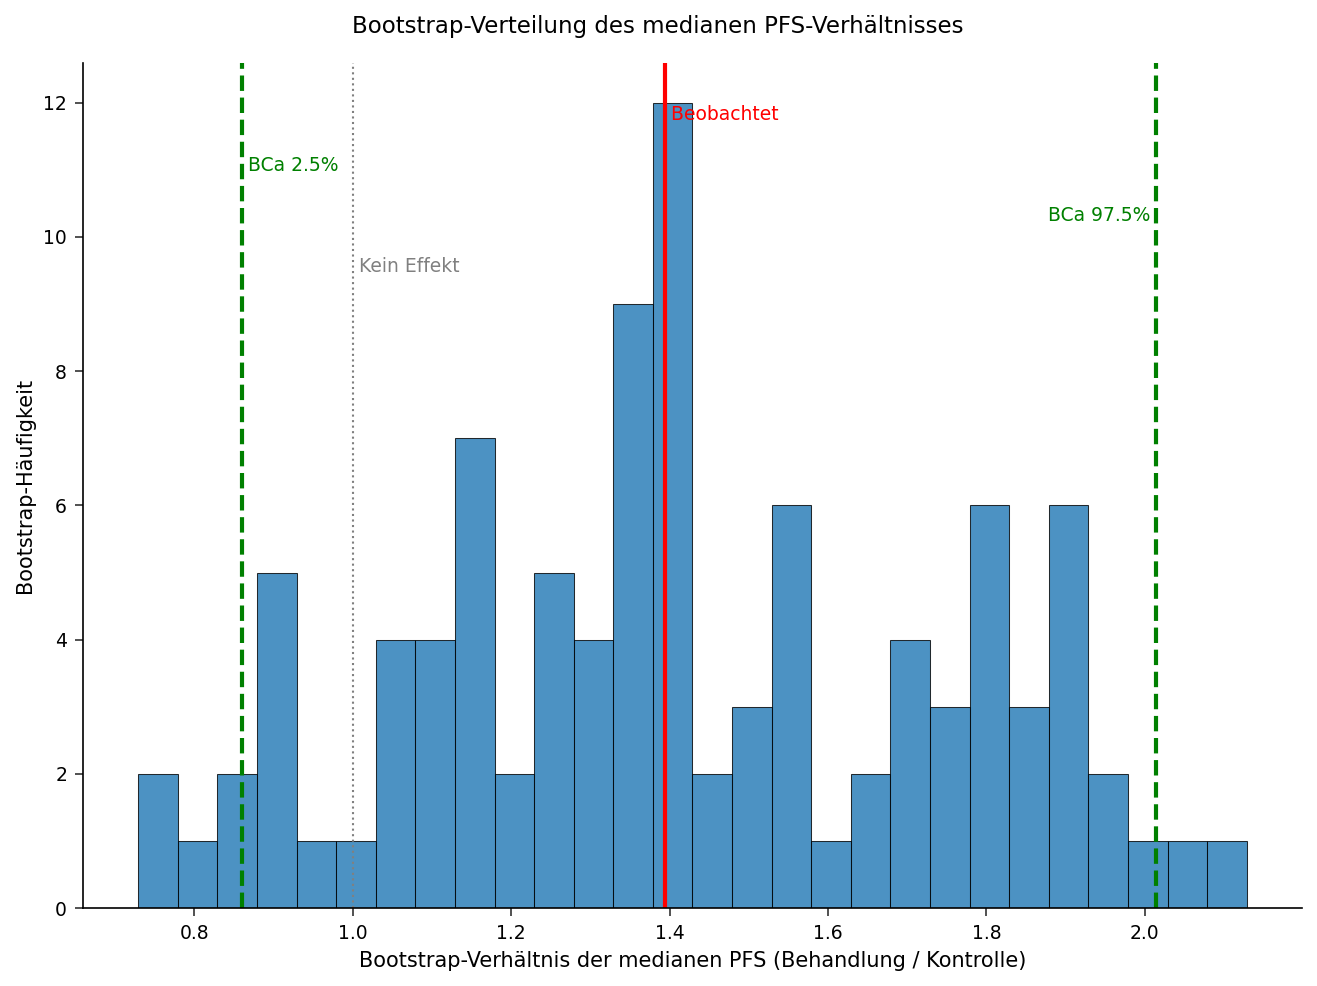

In [5]:
/* --------------------------------------------------------
   Bootstrap-Verteilung des medianen PFS-Verhältnisses, mit der
   beobachteten Schätzung und dem BCa-Intervall markiert.
   -------------------------------------------------------- */
PROZEDUR SGPLOT DATEN=work.bootstrap_results;
    HISTOGRAM RATIO / BINWIDTH=0.05
        fillattrs=(color=steelblue) TRANSPARENCY=0.2;
    REFLINE obs_ratio / AXIS=x
        LINEATTRS=(color=red thickness=2) BEZEICHNUNG='Beobachtet';
    REFLINE bca_lower / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        BEZEICHNUNG='BCa 2.5%';
    REFLINE bca_upper / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        BEZEICHNUNG='BCa 97.5%';
    REFLINE 1 / AXIS=x
        LINEATTRS=(color=gray thickness=1 pattern=dot)
        BEZEICHNUNG='Kein Effekt';
    XAXIS BEZEICHNUNG='Bootstrap-Verhältnis der medianen PFS (Behandlung / Kontrolle)';
    YAXIS BEZEICHNUNG='Bootstrap-Häufigkeit';
    TITEL 'Bootstrap-Verteilung des medianen PFS-Verhältnisses';
AUSFÜHREN;

---


### Interpretation

In dieser Kohorte beträgt der beobachtete Median der PFS über die Ereigniszeiten **9.9 Monate** im Behandlungsarm und **7.1 Monate** im Kontrollarm, ein **Verhältnis von 1.394** &mdash; die mediane PFS des experimentellen Arms ist etwa 39% länger. Das IML-Programm hat die 100 Probanden 2000 Mal resampled; alle 2000 Stichproben ergaben ein definiertes Verhältnis.

Das **BCa-95%-Konfidenzintervall für das Verhältnis ist [0.86, 2.01]**, gegenüber einem einfachen Perzentilintervall von **[0.82, 1.97]**. Beide Intervalle **schließen 1.0 ein**, sodass bei dieser Stichprobengröße &mdash; rund 50 Probanden je Arm, weiter ausgedünnt auf beobachtete Ereigniszeiten &mdash; der scheinbare Nutzen **statistisch nicht eindeutig** ist. Das ist die ehrliche Botschaft der Analyse: eine Punktschätzung zugunsten der Behandlung, aber mit genug Resampling-Unsicherheit, dass ein fehlender Behandlungseffekt nicht ausgeschlossen werden kann.

Die BCa-Diagnostik quantifiziert, wie stark die Korrektur die Endpunkte verschoben hat. Der Bias-Term ist klein (**z<sub>0</sub> = 0.085**: etwa 53% der Stichproben lagen unter dem beobachteten Verhältnis, nahe an den symmetrischen 50%), und die Beschleunigung ist nahe null (**a&#770; = -0.002**), was darauf hindeutet, dass das mediane PFS-Verhältnis nur schwach von einzelnen Probanden beeinflusst wird. Da z<sub>0</sub> und a&#770; beide klein sind, verschiebt BCa das Intervall nur leicht nach oben relativ zum Perzentilintervall &mdash; genau die moderate Korrektur, die diese Diagnostik erwarten lässt.

Eine größere Studie würde dieses Intervall verengen. Mit 50 Probanden je Arm meldet der Bootstrap zu Recht, dass die Daten mit allem von einer leichten Umkehr bis zu einer Verdopplung der medianen PFS vereinbar sind, weshalb eine Studie, die auf den Nachweis eines PFS-Unterschieds dieser Größe ausgelegt ist, deutlich mehr als 100 Probanden benötigt.

---


In [6]:
/* --------------------------------------------------------
   Bootstrap-Verteilung für einen Berichtsanhang exportieren.
   -------------------------------------------------------- */
PROZEDUR EXPORT DATEN=work.bootstrap_results
    OUTFILE='pfs_bootstrap_ci_results.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;


NOTE: PROC EXPORT data=work.bootstrap_results outfile=pfs_bootstrap_ci_results.csv

NOTE: Exported 100 rows to pfs_bootstrap_ci_results.csv.


---


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>